In [1]:
import os
import rasterio
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import backend as K
from sklearn.model_selection import train_test_split

print("TensorFlow Version:", tf.__version__)

# --- Configuration ---
IMAGE_DIR = '/Users/SONY/Documents/College/Study_pdeu/Res_Paper/AI/Poojamaam/Data/unet/data/images'
MASK_DIR = '/Users/SONY/Documents/College/Study_pdeu/Res_Paper/AI/Poojamaam/Data/unet/data/masks'
BATCH_SIZE = 4
IMG_HEIGHT = 608 
IMG_WIDTH = 496
NUM_CHANNELS = 5 
# UPDATED: We now have 7 real classes + 1 class for the 'No Data' background
NUM_CLASSES = 8  

def load_and_preprocess(image_path, mask_path):
    image_path = image_path.numpy().decode('utf-8')
    with rasterio.open(image_path) as src:
        image = src.read().astype(np.float32)
        image = np.transpose(image, (1, 2, 0))
    
    mask_path = mask_path.numpy().decode('utf-8')
    with rasterio.open(mask_path) as src:
        mask = src.read(1).astype(np.uint8)
        
        # --- NEW: Handle the 'No Data' value ---
        # We find all pixels with the value 255 and assign them to our new 'ignore' class (7)
        mask[mask == 255] = 7
        
        mask = np.expand_dims(mask, axis=-1)

    image = tf.image.resize_with_pad(image, IMG_HEIGHT, IMG_WIDTH)
    mask = tf.image.resize_with_pad(mask, IMG_HEIGHT, IMG_WIDTH, method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    mask = tf.squeeze(mask, axis=-1)
    image = image / 65535.0
    mask = tf.one_hot(tf.cast(mask, tf.uint8), depth=NUM_CLASSES, dtype=tf.float32)
    return image, mask

def create_split_datasets(image_dir, mask_dir):
    image_files = sorted([os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.endswith('.tif')])
    mask_files = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith('.tif')])
    train_files, test_val_files = train_test_split(list(zip(image_files, mask_files)), test_size=0.3, random_state=42)
    val_files, test_files = train_test_split(test_val_files, test_size=0.5, random_state=42)
    
    def create_tf_dataset(file_list):
        img_paths, msk_paths = zip(*file_list)
        dataset = tf.data.Dataset.from_tensor_slices((list(img_paths), list(msk_paths)))
        dataset = dataset.map(lambda img, msk: tf.py_function(load_and_preprocess, [img, msk], [tf.float32, tf.float32]))
        dataset = dataset.map(lambda img, msk: (
            tf.ensure_shape(img, [IMG_HEIGHT, IMG_WIDTH, NUM_CHANNELS]), 
            tf.ensure_shape(msk, [IMG_HEIGHT, IMG_WIDTH, NUM_CLASSES])
        ))
        return dataset

    train_dataset = create_tf_dataset(train_files)
    val_dataset = create_tf_dataset(val_files)
    test_dataset = create_tf_dataset(test_files)
    
    train_dataset = train_dataset.shuffle(buffer_size=100).batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)
    val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)
    test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)
    return train_dataset, val_dataset, test_dataset

# Create the datasets
train_dataset, val_dataset, test_dataset = create_split_datasets(IMAGE_DIR, MASK_DIR)
print("✅ Datasets created successfully!")

TensorFlow Version: 2.19.0
✅ Datasets created successfully!


In [2]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate
# ... [The build_unet function code is the same as before] ...
def build_unet(input_shape, num_classes):
    inputs = Input(input_shape)
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)
    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)
    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)
    c4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    p4 = MaxPooling2D((2, 2))(c4)
    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)
    u6 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)
    u7 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)
    u8 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
    c8 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)
    u9 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = concatenate([u9, c1])
    c9 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
    c9 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)
    outputs = Conv2D(num_classes, (1, 1), activation='softmax')(c9)
    model = Model(inputs=[inputs], outputs=[outputs])
    return model

input_shape = (IMG_HEIGHT, IMG_WIDTH, NUM_CHANNELS)
model = build_unet(input_shape, NUM_CLASSES)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 608, 496,  │          0 │ -                 │
│ (InputLayer)        │ 5)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 608, 496,  │        736 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 608, 496,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 304, 248,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 304, 248,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 304, 248,  │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 152, 124,  │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 152, 124,  │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 152, 124,  │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 76, 62,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 76, 62,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 76, 62,    │    147,584 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 38, 31,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 38, 31,    │    295,168 │ max_pooling2d_3[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 38, 31,    │    590,080 │ conv2d_8[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 76, 62,    │    131,200 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 76, 62,    │          0 │ conv2d_transpose

 Total params: 1,941,512 (7.41 MB)

 Trainable params: 1,941,512 (7.41 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
def dice_loss(y_true, y_pred, smooth=1e-6):
    # This loss will be calculated on the valid classes only
    y_pred_valid = y_pred[:,:,:,:-1] # Exclude the last 'ignore' class
    y_true_valid = y_true[:,:,:,:-1] # Exclude the last 'ignore' class
    
    intersection = K.sum(y_true_valid * y_pred_valid, axis=[1, 2, 3])
    union = K.sum(y_true_valid, axis=[1, 2, 3]) + K.sum(y_pred_valid, axis=[1, 2, 3])
    dice = K.mean((2. * intersection + smooth) / (union + smooth), axis=0)
    return 1 - dice

def focal_loss(y_true, y_pred, gamma=2.0, alpha=0.25):
    # This loss will be calculated on the valid classes only
    y_pred_valid = y_pred[:,:,:,:-1] # Exclude the last 'ignore' class
    y_true_valid = y_true[:,:,:,:-1] # Exclude the last 'ignore' class

    epsilon = K.epsilon()
    y_pred_valid = K.clip(y_pred_valid, epsilon, 1. - epsilon)
    cross_entropy = -y_true_valid * K.log(y_pred_valid)
    loss = alpha * K.pow(1 - y_pred_valid, gamma) * cross_entropy
    return K.mean(K.sum(loss, axis=-1))

def combined_loss(y_true, y_pred):
    return focal_loss(y_true, y_pred) + dice_loss(y_true, y_pred)

print("✅ Custom loss function that ignores the background class defined.")

✅ Custom loss function that ignores the background class defined.


In [4]:
EPOCHS = 75
LEARNING_RATE = 0.0005

optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=optimizer,
              loss=combined_loss, # <-- USING THE NEW LOSS
              metrics=['accuracy', tf.keras.metrics.MeanIoU(num_classes=NUM_CLASSES)])

print("✅ Model compiled successfully. Starting training...")

history = model.fit(train_dataset,
                    epochs=EPOCHS,
                    validation_data=val_dataset)

print("✅ Training finished!")

✅ Model compiled successfully. Starting training...
Epoch 1/75


/opt/miniconda3/envs/tf_env/lib/python3.12/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 608, 496, 5))
  warnings.warn(msg)


3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.5165 - loss: 1.2628 - mean_io_u: 0.4375 - val_accuracy: 0.6987 - val_loss: 1.2542 - val_mean_io_u: 0.4375
Epoch 2/75
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.6957 - loss: 1.2501 - mean_io_u: 0.4375 - val_accuracy: 0.6790 - val_loss: 1.2079 - val_mean_io_u: 0.4375
Epoch 3/75
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.6752 - loss: 1.1735 - mean_io_u: 0.4375 - val_accuracy: 0.6936 - val_loss: 1.0645 - val_mean_io_u: 0.4375
Epoch 4/75
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.6901 - loss: 1.0441 - mean_io_u: 0.4375 - val_accuracy: 0.6996 - val_loss: 0.8933 - val_mean_io_u: 0.4375
Epoch 5/75
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.6995 - loss: 0.8577 - mean_io_u: 0.4375 - val_accuracy: 0.7015 - val_loss: 0.7360 - val_mean_io_u: 0.4375
Epoch 6/75
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.6990 - loss: 0.7027 - mean_io_u: 0.4375 - val_accuracy: 0.7019 - val_loss: 0.5700 - val_mean_io_u: 0.4375
Epoch

Available metric keys: dict_keys(['accuracy', 'loss', 'mean_io_u', 'val_accuracy', 'val_loss', 'val_mean_io_u'])


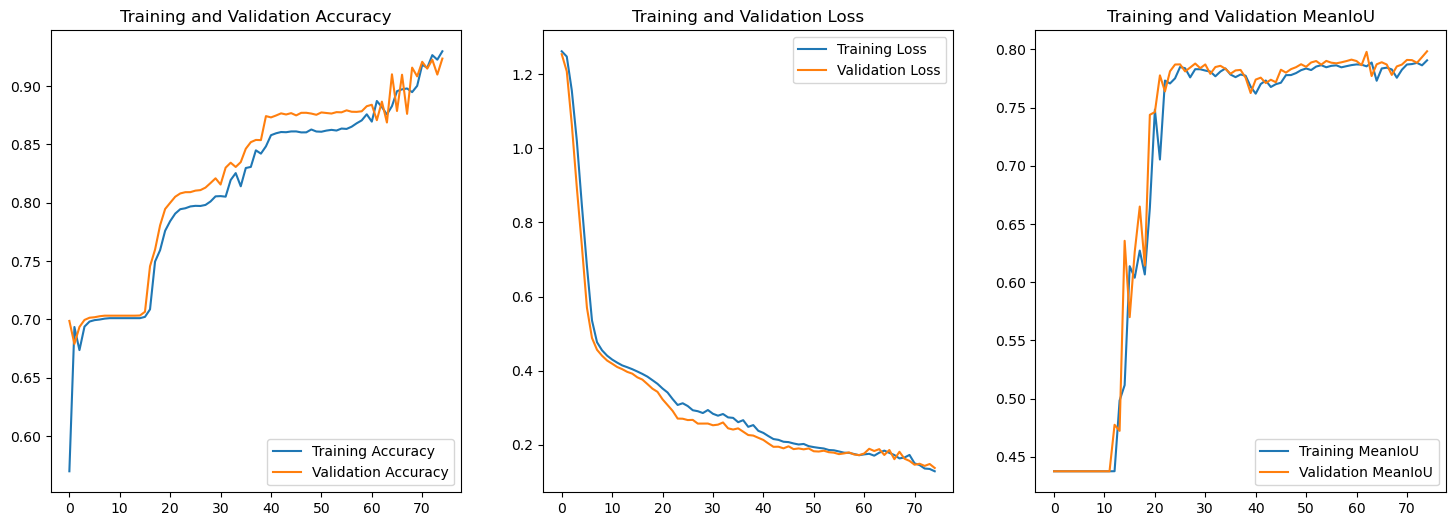

In [5]:
print("Available metric keys:", history.history.keys())
# Check the output above and update the keys here if they are different
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
mean_iou_key = 'mean_iou' if 'mean_iou' in history.history else 'mean_io_u'
mean_iou = history.history[mean_iou_key] 
val_mean_iou = history.history['val_' + mean_iou_key] 
epochs_range = range(len(acc))

plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.subplot(1, 3, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.subplot(1, 3, 3)
plt.plot(epochs_range, mean_iou, label='Training MeanIoU')
plt.plot(epochs_range, val_mean_iou, label='Validation MeanIoU')
plt.legend(loc='lower right')
plt.title('Training and Validation MeanIoU')
plt.show()

/opt/miniconda3/envs/tf_env/lib/python3.12/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(3, 608, 496, 5))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 878ms/step


2025-08-28 02:46:11.924560: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


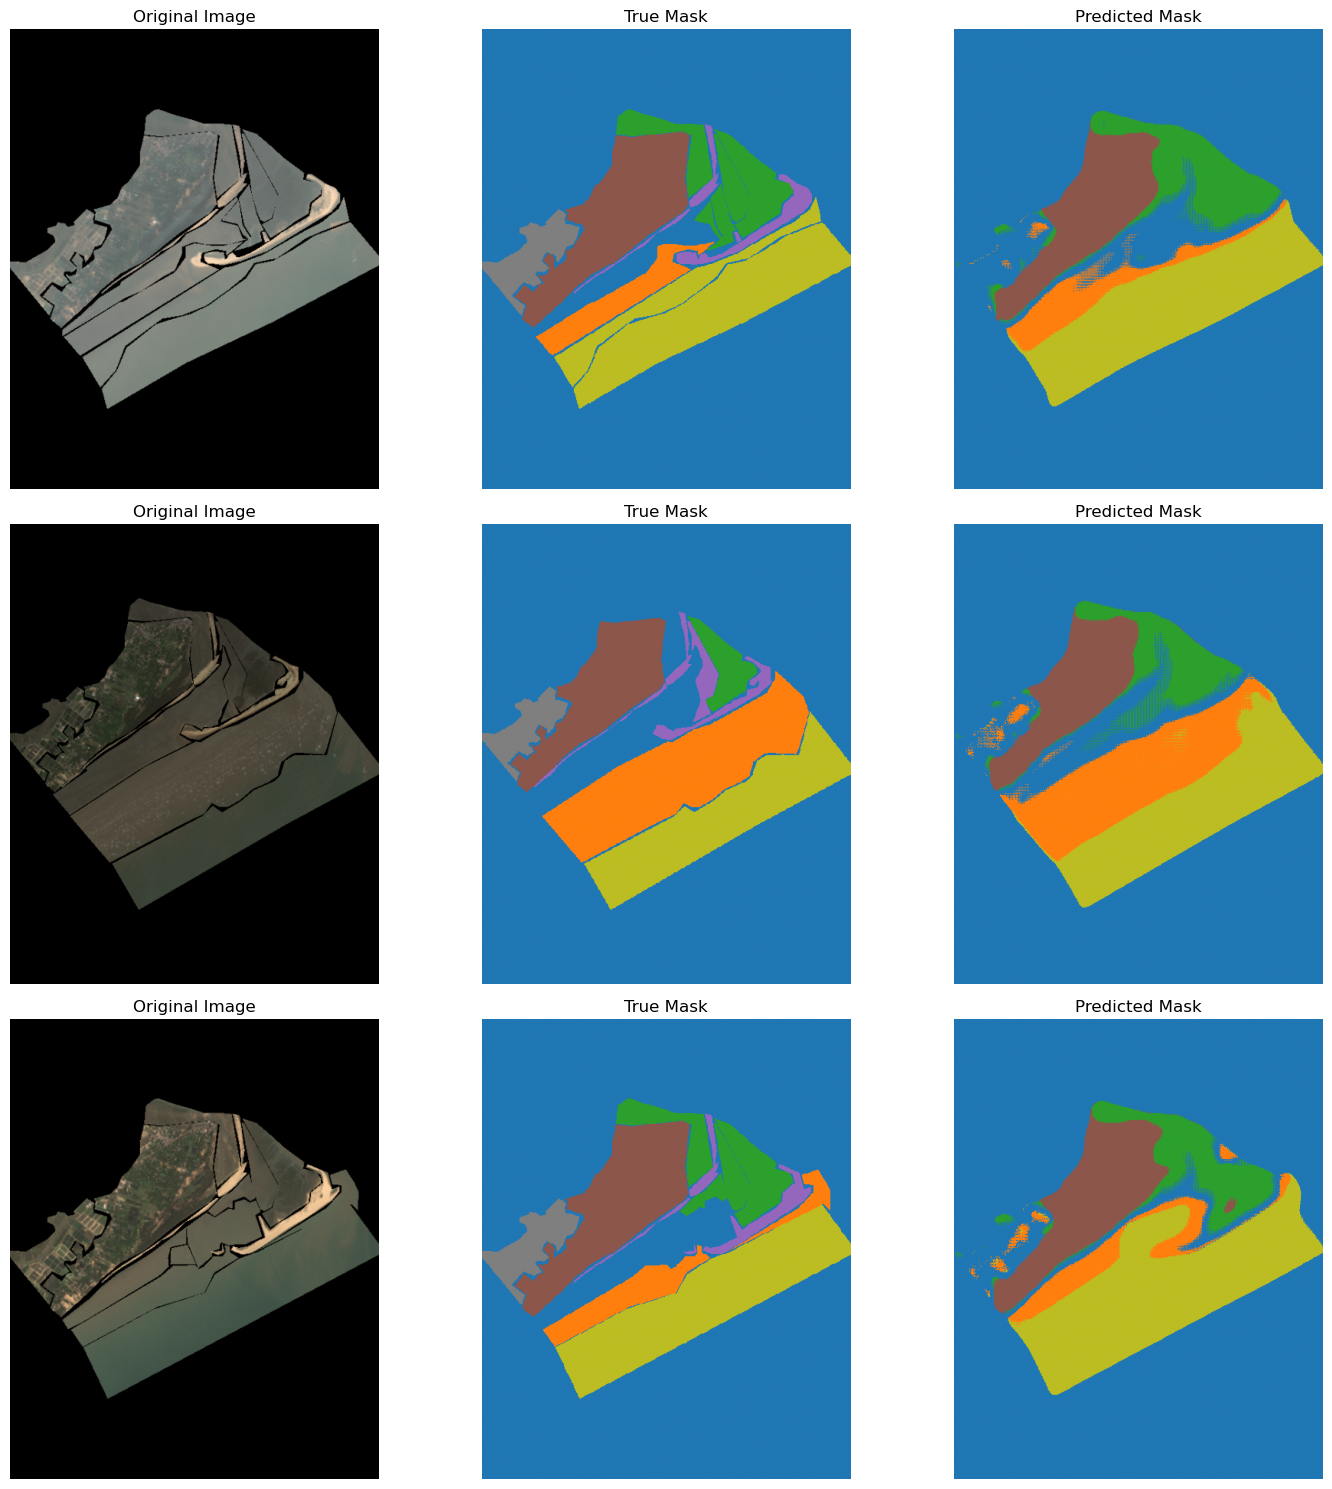

In [6]:
class_names = [
    "0: TFNS", "1: TFAS", "2: Mudflat+Mangrove", "3: Sandy beach", 
    "4: Agri Patches", "5: Aqua Ports", "6: Water"
]
cmap = plt.get_cmap('tab10', NUM_CLASSES) 

# Take a batch from the test dataset to visualize
for images, masks in test_dataset.take(1):
    predictions = model.predict(images)
    predicted_masks = np.argmax(predictions, axis=-1)
    true_masks = np.argmax(masks, axis=-1)

num_to_display = len(images) # Display all images in the batch
plt.figure(figsize=(15, 5 * num_to_display))
for i in range(num_to_display):
    # Un-pad the images and masks back to their original aspect ratio for a better view
    original_h, original_w = 601, 482
    h_pad = (IMG_HEIGHT - original_h) // 2
    w_pad = (IMG_WIDTH - original_w) // 2
    
    image_unpadded = images[i][h_pad:h_pad+original_h, w_pad:w_pad+original_w, :]
    true_mask_unpadded = true_masks[i][h_pad:h_pad+original_h, w_pad:w_pad+original_w]
    predicted_mask_unpadded = predicted_masks[i][h_pad:h_pad+original_h, w_pad:w_pad+original_w]

    # Display Original Image
    image_np = image_unpadded.numpy()
    rgb_image = image_np[:, :, [2, 1, 0]]
    rgb_image = (rgb_image - np.min(rgb_image)) / (np.max(rgb_image) - np.min(rgb_image) + 1e-6)
    
    ax = plt.subplot(num_to_display, 3, i * 3 + 1)
    ax.imshow(rgb_image)
    ax.set_title("Original Image")
    ax.axis("off")

    # Display True Mask
    ax = plt.subplot(num_to_display, 3, i * 3 + 2)
    ax.imshow(true_mask_unpadded, cmap=cmap, vmin=0, vmax=NUM_CLASSES - 1)
    ax.set_title("True Mask")
    ax.axis("off")

    # Display Predicted Mask
    ax = plt.subplot(num_to_display, 3, i * 3 + 3)
    ax.imshow(predicted_mask_unpadded, cmap=cmap, vmin=0, vmax=NUM_CLASSES - 1)
    ax.set_title("Predicted Mask")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [9]:
# -*- coding: utf-8 -*-
"""
Script to find the optimal batch size and number of epochs for the U-Net model
by running automated training experiments.
"""

# --- Core Libraries ---
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

# --- FIX: Set Framework Environment Variable ---
os.environ["SM_FRAMEWORK"] = "tf.keras"

# --- Deep Learning Libraries ---
import tensorflow as tf
from tensorflow import keras

# --- Geospatial and Data Handling ---
import rasterio

# --- Model Building ---
import segmentation_models as sm

# --- Set a random seed for reproducibility ---
tf.random.set_seed(42)
np.random.seed(42)

# ===================================================================
# 1. CONFIGURATION
# ===================================================================

# ✏️ UPDATE these paths and parameters as needed
DATA_DIR = '/Users/SONY/Documents/College/Study_pdeu/Res_Paper/AI/Poojamaam/Data/unet/data'
BATCH_SIZES_TO_TEST = [2,4,6,8]  # List of batch sizes to experiment with
MAX_EPOCHS = 100  # The maximum number of epochs for any single run
N_CLASSES = 5
BACKBONE = 'efficientnetb0'
INPUT_SHAPE = (256, 256, 5)

# ===================================================================
# 2. DATA LOADER (Copied from your notebook)
# ===================================================================

class CustomDataset(keras.utils.Sequence):
    def __init__(self, image_dir, mask_dir, batch_size=16, patch_size=256):
        self.image_paths = sorted([os.path.join(image_dir, fname) for fname in os.listdir(image_dir) if fname.endswith('.tif')])
        self.mask_paths = sorted([os.path.join(mask_dir, fname) for fname in os.listdir(mask_dir) if fname.endswith('.tif')])
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.n_classes = N_CLASSES

    def __len__(self):
        return len(self.mask_paths) // self.batch_size

    def __getitem__(self, idx):
        i = idx * self.batch_size
        batch_image_paths = self.image_paths[i : i + self.batch_size]
        batch_mask_paths = self.mask_paths[i : i + self.batch_size]
        
        x = np.zeros((self.batch_size, self.patch_size, self.patch_size, 5), dtype="float32")
        y = np.zeros((self.batch_size, self.patch_size, self.patch_size, self.n_classes), dtype="float32")

        for j, (img_path, msk_path) in enumerate(zip(batch_image_paths, batch_mask_paths)):
            with rasterio.open(img_path) as src:
                image = src.read().transpose(1, 2, 0)
            with rasterio.open(msk_path) as src:
                mask = src.read(1)
            
            x[j] = image / 65535.0
            y[j] = tf.one_hot(mask.astype(np.int32), depth=self.n_classes)

        return x, y

# ===================================================================
# 3. MODEL BUILDER (Copied from your notebook)
# ===================================================================

def build_model(backbone, n_classes, input_shape):
    """Builds a U-Net model."""
    model = sm.Unet(
        backbone, 
        classes=n_classes, 
        activation='softmax', 
        input_shape=input_shape,
        encoder_weights=None,
    )
    return model

# ===================================================================
# 4. EXPERIMENT AND TUNING LOOP
# ===================================================================

def run_tuning_experiments():
    """
    Trains the model with different batch sizes and uses Early Stopping
    to find the optimal number of epochs for each.
    """
    # --- Define file paths ---
    TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'train', 'images')
    TRAIN_MSK_DIR = os.path.join(DATA_DIR, 'train', 'masks')
    VAL_IMG_DIR = os.path.join(DATA_DIR, 'val', 'images')
    VAL_MSK_DIR = os.path.join(DATA_DIR, 'val', 'masks')
    
    results = {}

    for batch_size in BATCH_SIZES_TO_TEST:
        start_time = time.time()
        print("\n" + "="*60)
        print(f"🚀 STARTING EXPERIMENT: BATCH_SIZE = {batch_size}")
        print("="*60)

        # 1. Create DataLoaders with the current batch size
        print("   - Creating data loaders...")
        train_dataset = CustomDataset(TRAIN_IMG_DIR, TRAIN_MSK_DIR, batch_size=batch_size)
        val_dataset = CustomDataset(VAL_IMG_DIR, VAL_MSK_DIR, batch_size=batch_size)
        
        if len(train_dataset) == 0 or len(val_dataset) == 0:
            print(f"   - ⚠️ SKIPPING: Not enough data for batch size {batch_size}. Need at least {batch_size} patches in train and val sets.")
            continue

        # 2. Build and Compile a fresh model
        print("   - Building and compiling model...")
        model = build_model(BACKBONE, N_CLASSES, INPUT_SHAPE)
        metrics = [sm.metrics.IOUScore(threshold=0.5, name='iou_score')]
        optimizer = keras.optimizers.AdamW(learning_rate=1e-4)
        model.compile(optimizer=optimizer, loss=tf.keras.losses.CategoricalCrossentropy(), metrics=metrics)

        # 3. Define Callbacks with Early Stopping
        # This is the key to finding the optimal number of epochs automatically.
        callbacks = [
            keras.callbacks.EarlyStopping(
                monitor='val_iou_score', # The metric to watch
                patience=10,             # Number of epochs with no improvement to wait before stopping
                verbose=1,
                mode='max',              # We want to maximize IoU score
                restore_best_weights=True # Restores the weights from the epoch with the best score
            )
        ]

        # 4. Train the model
        print(f"   - Starting training for up to {MAX_EPOCHS} epochs...")
        history = model.fit(
            train_dataset,
            epochs=MAX_EPOCHS,
            validation_data=val_dataset,
            callbacks=callbacks,
            verbose=2 # Use 2 for less output per epoch
        )

        # 5. Record the results
        best_val_iou = max(history.history['val_iou_score'])
        optimal_epochs = len(history.history['val_iou_score']) # The number of epochs it actually ran
        training_time = time.time() - start_time
        
        results[batch_size] = {
            'best_val_iou': best_val_iou,
            'optimal_epochs': optimal_epochs,
            'training_time_seconds': training_time
        }
        print(f"   - ✅ FINISHED Experiment for BATCH_SIZE = {batch_size} in {training_time:.2f} seconds.")

    # --- Print the final summary of all experiments ---
    print("\n\n" + "="*60)
    print("📊 HYPERPARAMETER TUNING SUMMARY")
    print("="*60)
    print(f"{'Batch Size':<15} | {'Best Val IoU':<15} | {'Optimal Epochs':<18} | {'Time (s)':<10}")
    print("-" * 60)
    
    # Find the best run
    best_batch_size = None
    best_score = -1

    for batch_size, result in results.items():
        print(f"{batch_size:<15} | {result['best_val_iou']:.4f}{' ':<10} | {result['optimal_epochs']:<18} | {result['training_time_seconds']:.0f}")
        if result['best_val_iou'] > best_score:
            best_score = result['best_val_iou']
            best_batch_size = batch_size
    
    print("-" * 60)
    print(f"\n🏆 Best performing batch size: {best_batch_size} with a validation IoU of {best_score:.4f}")
    print("="*60)


if __name__ == "__main__":
    run_tuning_experiments()


🚀 STARTING EXPERIMENT: BATCH_SIZE = 2
   - Creating data loaders...


FileNotFoundError: [Errno 2] No such file or directory: '/Users/SONY/Documents/College/Study_pdeu/Res_Paper/AI/Poojamaam/Data/unet/data/train/images'